# $(SA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1612,17,69,"(0.35, 1.7)","(0.195, 0.563, -0.056, -0.296)",1,1.0,"(0.207, 0.75, -0.062, -0.407)",0.0,1.0,"(0.222, 0.563, -0.07, -0.309)"
111,31,4,"(0.65, 1.6)","(0.305, 0.95, -0.173, -0.93)",1,1.0,"(0.324, 1.14, -0.192, -1.105)",1.0,1.0,"(0.347, 1.329, -0.214, -1.281)"
1739,34,72,"(0.67, 1.6)","(-0.228, -0.804, 0.099, 0.561)",0,1.0,"(-0.245, -0.993, 0.11, 0.732)",1.0,1.0,"(-0.264, -0.805, 0.124, 0.596)"
1698,20,71,"(0.85, 1.7)","(-0.032, -0.76, 0.048, 0.803)",1,1.0,"(-0.047, -0.57, 0.064, 0.623)",0.0,1.0,"(-0.058, -0.761, 0.077, 0.825)"
526,17,24,"(0.68, 1.3)","(-0.059, 0.174, 0.063, -0.043)",0,1.0,"(-0.056, -0.017, 0.062, 0.165)",0.0,1.0,"(-0.056, -0.208, 0.065, 0.372)"
...,...,...,...,...,...,...,...,...,...,...
729,0,32,"(0.92, 0.9)","(-0.034, 0.007, -0.012, -0.018)",1,1.0,"(-0.034, 0.208, -0.013, -0.429)",1.0,1.0,"(-0.03, 0.408, -0.021, -0.841)"
576,33,26,"(0.23, 1.9)","(-0.39, -0.959, 0.142, 0.542)",0,1.0,"(-0.409, -1.145, 0.153, 0.639)",0.0,1.0,"(-0.432, -1.331, 0.166, 0.737)"
1143,51,49,"(0.23, 1.3)","(0.128, 1.324, -0.117, -0.919)",1,1.0,"(0.155, 1.512, -0.135, -1.058)",0.0,1.0,"(0.185, 1.325, -0.156, -0.953)"
462,2,22,"(0.98, 0.1)","(-0.007, -0.015, -0.126, -0.331)",1,1.0,"(-0.007, 0.369, -0.133, -4.822)",1.0,1.0,"(0.0, 0.748, -0.229, -9.262)"


In [3]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.17182758450508118, 0.5909345149993896, 0.05...",1.904846,0.769975
1,1,"[0.1690972000360489, 0.5859774947166443, 0.050...",1.890751,0.765444
2,2,"[0.16640633344650269, 0.5810714364051819, 0.04...",1.876801,0.760964
3,3,"[0.16375388205051422, 0.5762181282043457, 0.04...",1.862997,0.756534
4,4,"[0.16113825142383575, 0.5714198350906372, 0.04...",1.849338,0.752153


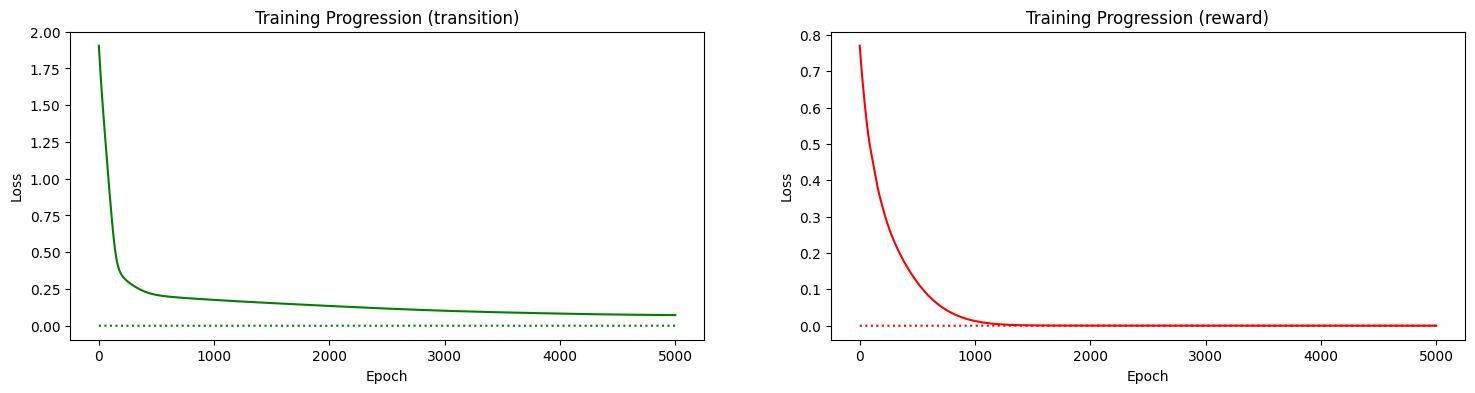

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

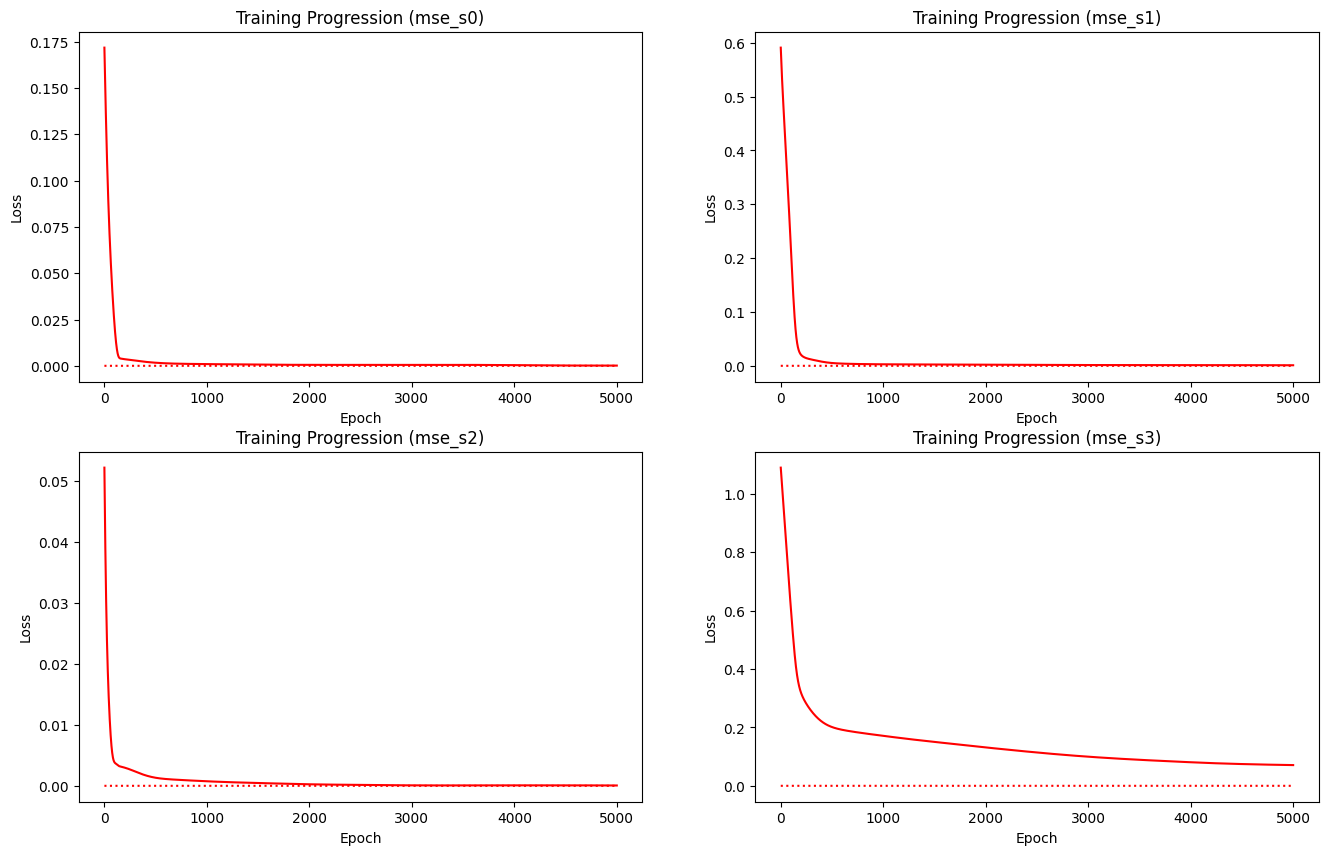

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

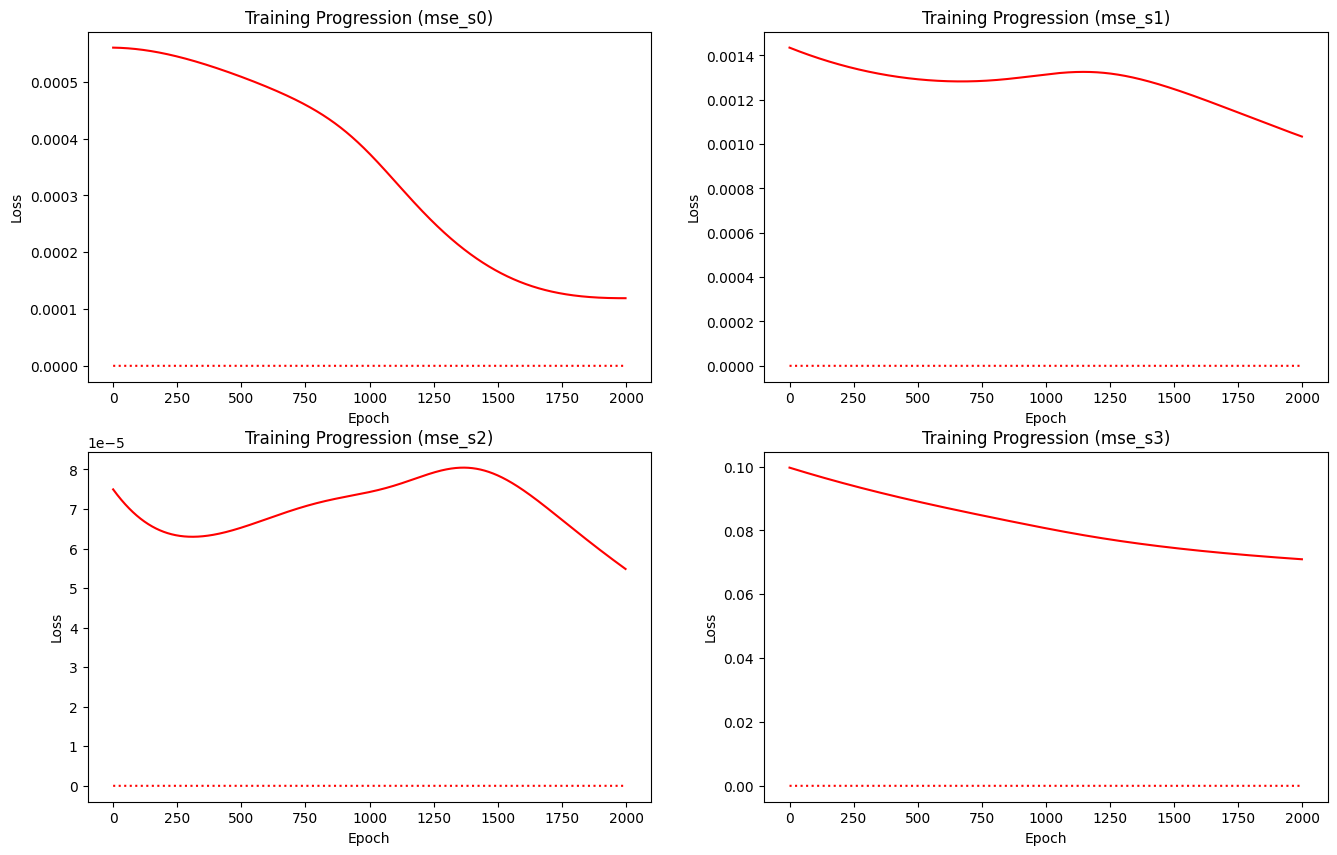

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data[train_data.epoch>3000].reset_index(drop=True), expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s3,estimated_s0,estimated_s1,estimated_s2,estimated_s3,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.018,-0.011,-0.048,-0.016,-0.120,0.001,0.006,0.000,0.102,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.218,-0.010,0.145,-0.014,-0.315,0.001,0.004,0.002,0.097,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.418,-0.004,0.340,-0.015,-0.483,0.004,0.000,0.006,0.065,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.619,0.006,0.536,-0.022,-0.644,0.007,0.005,0.007,0.025,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.822,0.020,0.731,-0.033,-0.817,0.011,0.009,0.008,0.005,0.0


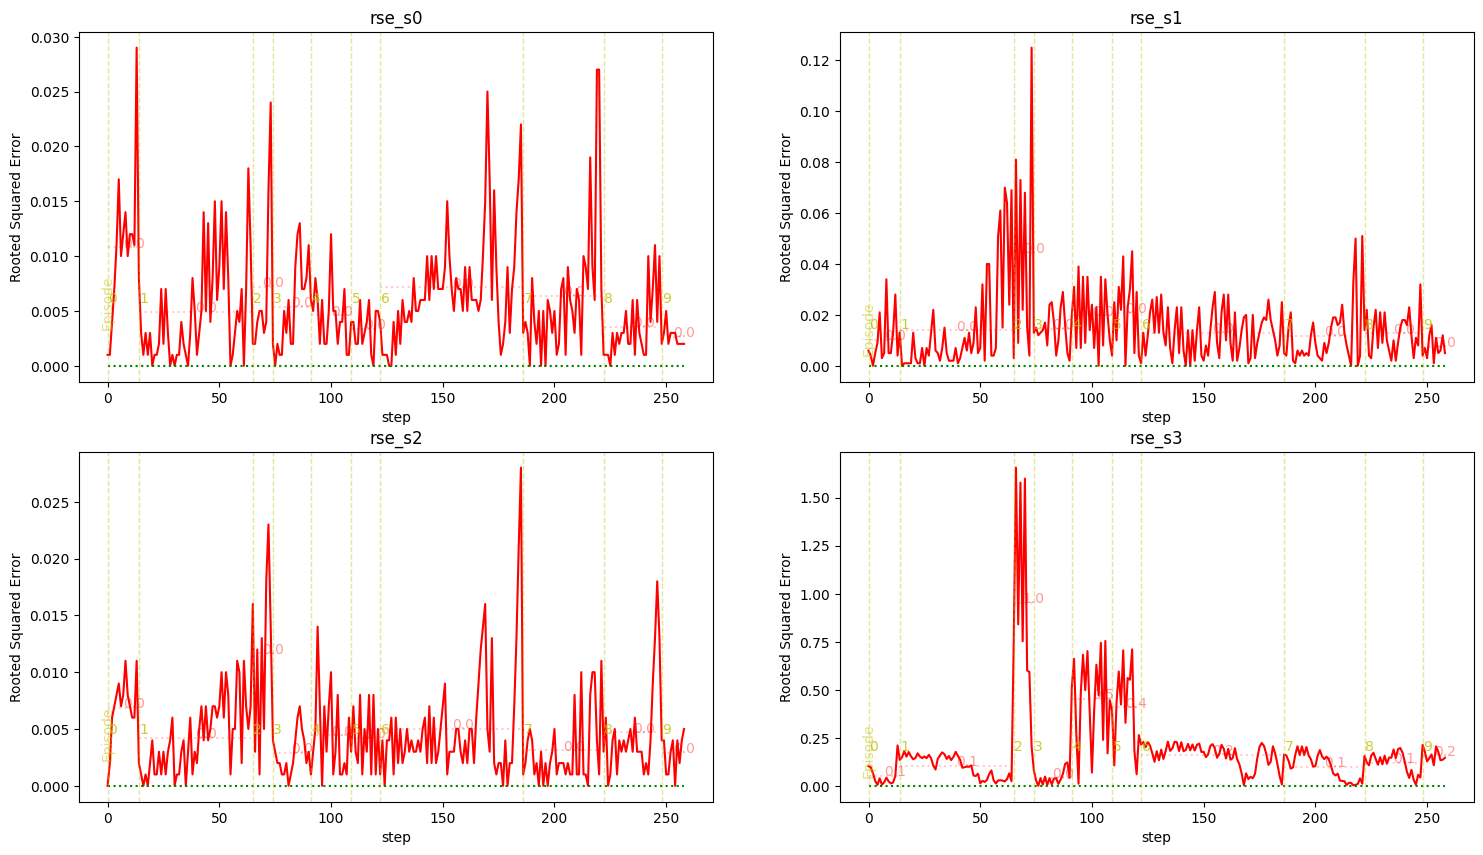

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

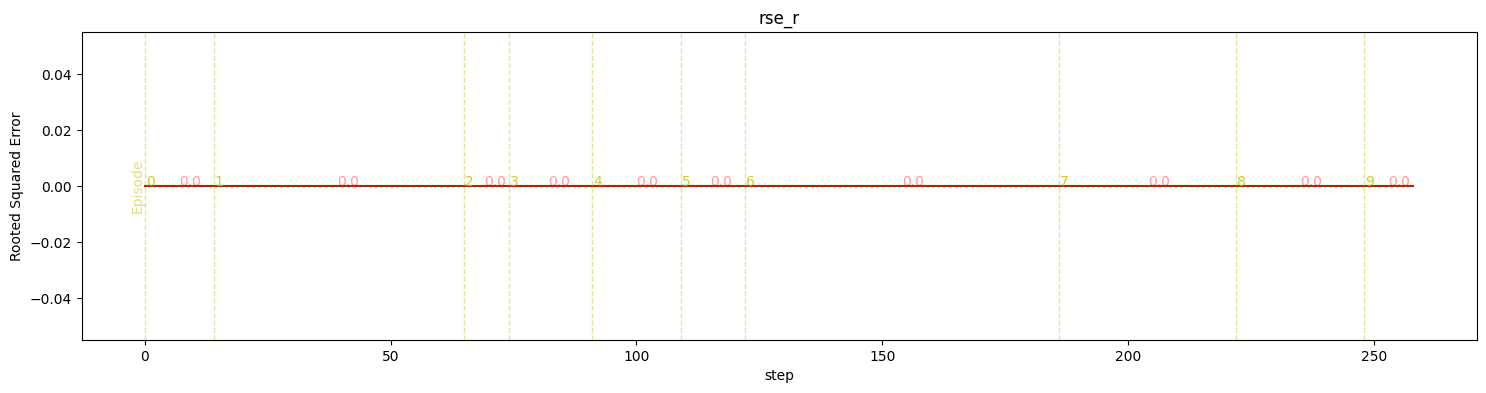

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

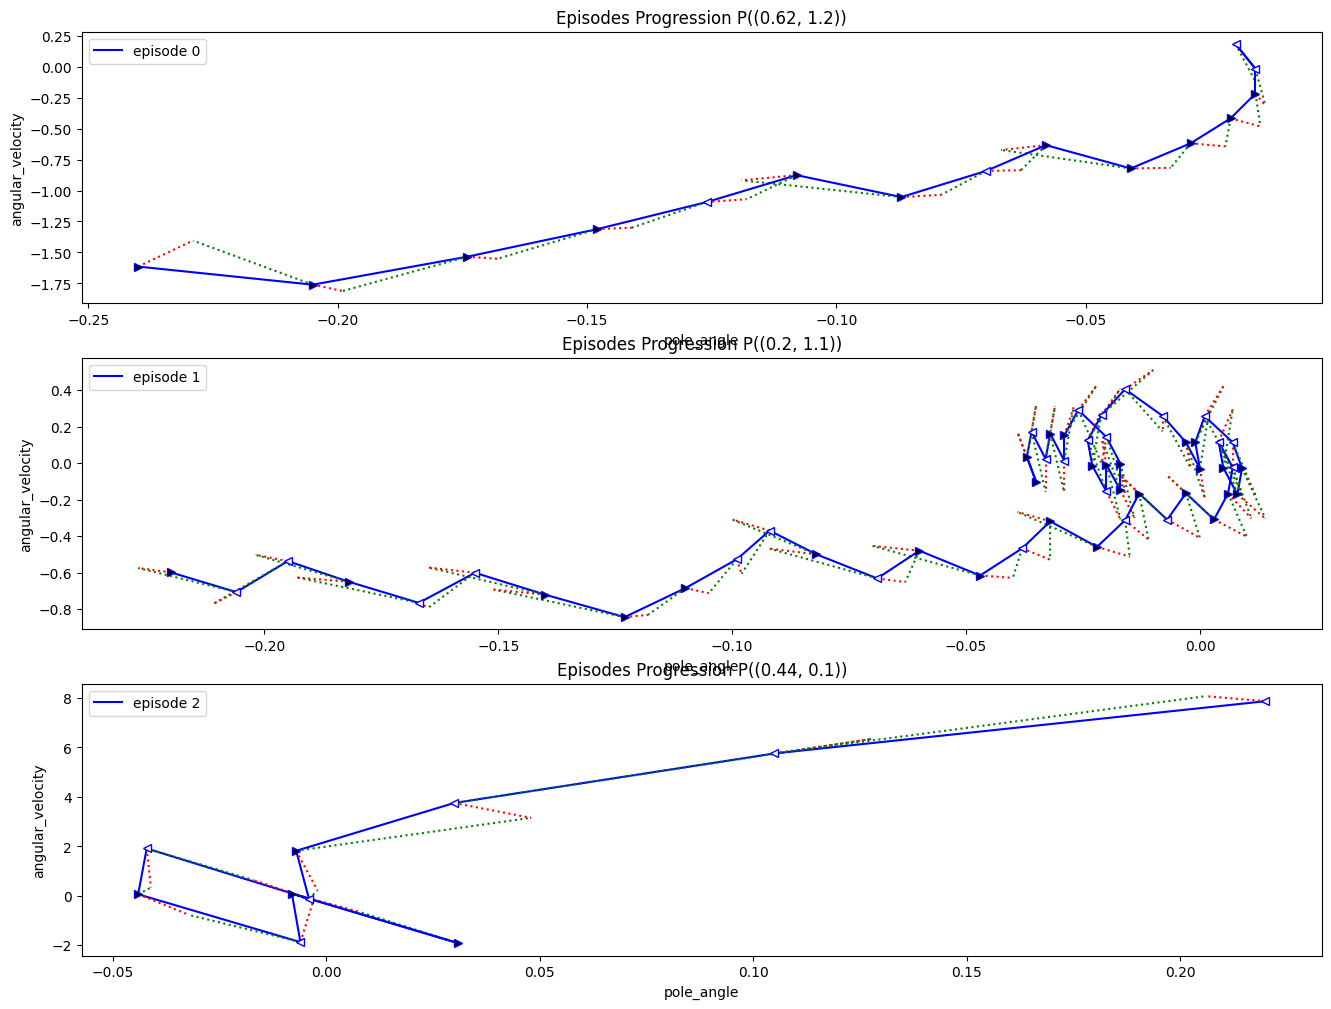

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()